In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Circle
from scipy.interpolate import interp1d
import pandas as pd
import sncosmo
from scipy import stats
from scipy.special import expit
from nested_pandas import read_parquet
from joblib import Parallel, delayed
import cloudpickle as pickle
from regions import RectangleSkyRegion
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.time import Time
import inspect
from IPython.display import display, Markdown

from lightcurvelynx.obstable.ztf_obstable import ZTFObsTable
from lightcurvelynx.astro_utils.passbands import PassbandGroup
from lightcurvelynx.astro_utils.pzflow_node import PZFlowNode
from lightcurvelynx.astro_utils.snia_utils import (
    DistModFromRedshift,
    HostmassX1Func,
    X0FromDistMod,
    num_snia_per_redshift_bin,
    SNCoordGivenPhysicalSep,
    snia_volumetric_rates,
)
from lightcurvelynx.math_nodes.scipy_random import SamplePDF
from lightcurvelynx.math_nodes.np_random import NumpyRandomFunc
from lightcurvelynx.simulate import simulate_lightcurves
from lightcurvelynx.models.sncosmo_models import SncosmoWrapperModel
from lightcurvelynx.models.snia_host import SNIaHost
from lightcurvelynx.utils.plotting import plot_lightcurves
from lightcurvelynx.math_nodes.ra_dec_sampler import ObsTableUniformRADECSampler
from lightcurvelynx.astro_utils.dustmap import DustmapWrapper,SFDMap
from lightcurvelynx.effects.extinction import ExtinctionEffect
from lightcurvelynx.astro_utils.mag_flux import mag2flux,flux2mag
from lightcurvelynx.astro_utils.detector_footprint import DetectorFootprint
from lightcurvelynx.utils.extrapolate import LinearDecayOnMag,ZeroPadding

from lightcurvelynx import _LIGHTCURVELYNX_BASE_DATA_DIR

from utils.lcfit import fit_single_lc
from utils.plotting_utils import plot_coverage_map
from utils.analysis_utils import lc_quality_cuts, spec_selection_func

from ztf_snia_sim_params import SIM_PARAMS

In [2]:
quick_test = False
NSIM = 3000
RANDSEED = 1024

In [3]:
RNG = np.random.default_rng(RANDSEED)

In [4]:
# load and define constants that are used throughout the simulations
H0 = SIM_PARAMS["H0"]
OMEGA_M = SIM_PARAMS["Omega_m"]
ALPHA = SIM_PARAMS["alpha"]
BETA = SIM_PARAMS["beta"]
ZMIN = SIM_PARAMS["zmin"]
ZMAX = SIM_PARAMS["zmax"]
MAGABS = SIM_PARAMS["mag_abs"]
SIGMA_MAGABS = SIM_PARAMS["sigma_mag_abs"]

ZP_ERR_MAG = SIM_PARAMS["zp_mag_err"]

In [5]:
globalhostdata = pd.read_csv('ztfsniadr2/tables/globalhost_data.csv')
localhostdata = pd.read_csv('ztfsniadr2/tables/localhost_data.csv')
sndata = pd.read_csv('ztfsniadr2/tables/snia_data.csv')
data = pd.merge(sndata,globalhostdata,on='ztfname')

In [6]:
%%time

obs_log = pd.read_parquet('data/ztf_observing_log_combined_w_metadata.parquet')
colmap = {"ra":"ra",
          "dec":"dec",
          "time":"mjd",
          "zp":"zp_nJy",
          "filter":"filter",
          "sky":"sky_adu_ztfsn",
         }

#ztf ccd size 6144 × 6160 pixel * 16
pixel_scale = 1.01 #arcsec/pixel
center = SkyCoord(ra=0.0, dec=0.0, unit="deg", frame="icrs")
rect_region = RectangleSkyRegion(center=center, width=7.323 * u.deg, 
                                 height=7.504 * u.deg, angle=0.0 * u.deg) # Dekany 2020 Table 3
ztf_fp = DetectorFootprint(rect_region, pixel_scale=pixel_scale)

ztf_obstable = ZTFObsTable(obs_log,colmap=colmap,detector_footprint=ztf_fp)
ztf_obstable.survey_values["zp_err_mag"] = ZP_ERR_MAG

t_min, t_max = ztf_obstable.time_bounds()
print(f"Loaded OpSim with {len(ztf_obstable)} rows and times [{t_min}, {t_max}]")

passband_group = PassbandGroup.from_preset(preset="ZTF", filters=["g", "r", "i"])
print(f"Loaded Passbands: {passband_group}")

Loaded OpSim with 522192 rows and times [58288.171875, 59273.55859375]
Loaded Passbands: PassbandGroup containing 3 passbands: ZTF_g, ZTF_r, ZTF_i
CPU times: user 544 ms, sys: 149 ms, total: 693 ms
Wall time: 605 ms


In [15]:
# Load the Flow model into a PZFlow node. This gives access to all of the outputs of the
# flow model as attributes of the PZFlowNode.
pz_node = PZFlowNode.from_file("data/ztfsniadr2_host_sn_before_selection_pzflow.pkl",  # filename
    node_label="pznode",
)
radec_node = ObsTableUniformRADECSampler(ztf_obstable, node_label="radec")

# Create a model for the host of the SNIa. The attributes will be sampled via
# the PZFlowNode's model. So each hos instantiation will have its own properties.
# Note: This requires the user to know the output names from the underlying flow model.

rate = lambda z: 2.35e-5 #(2.35 ± 0.24) × 10^4 Gpc^−3 yr^−1 = (2.35 ± 0.24) × 10^4 * 10^-9 Mpc^−3 yr^−1, from ZTF BTS paper Perley et al. 2020

nsn, z = num_snia_per_redshift_bin(ZMIN, ZMAX, 100, H0=H0, Omega_m=OMEGA_M, vol_rate_function=rate)
zpdf = interp1d(z, nsn, bounds_error=False, fill_value=0)

host = SNIaHost(
    ra = radec_node.ra,
    dec = radec_node.dec,
    hostmass=pz_node.mass,
    redshift=NumpyRandomFunc("uniform",low=0.002,high=0.005),
    node_label="host",
)

In [16]:
distmod_func = DistModFromRedshift(host.redshift, H0=H0, Omega_m=OMEGA_M)

m_abs_func = NumpyRandomFunc("normal", loc=MAGABS, scale=SIGMA_MAGABS)

# we model host-sn separation as an exponential distribution based on Fig 3 of Gupta et al 2016, mean separation = 5kpc
physical_host_sn_sep = NumpyRandomFunc("exponential", scale = 5.)
sncoor_node = SNCoordGivenPhysicalSep(host.ra, host.dec, physical_host_sn_sep, host.redshift, H0=H0, Omega_m=OMEGA_M,node_label='sncoor_node')

x0_func = X0FromDistMod(
    distmod=distmod_func,
    x1=pz_node.x1,
    c=pz_node.c,
    alpha=ALPHA,
    beta=BETA,
    m_abs=m_abs_func,
    node_label="x0_func",
)

sncosmo_modelname = "salt3"
time_extrap_before = ZeroPadding()
time_extrap_after = LinearDecayOnMag(decay_rate=0.02, mag_thres=30.)
wave_extrap_before = ZeroPadding()
wave_extrap_after = ZeroPadding()
source = SncosmoWrapperModel(
    sncosmo_modelname,
    t0=NumpyRandomFunc("uniform", low=t_min, high=t_max),
    x0=x0_func,
    x1=pz_node.x1,
    c=pz_node.c,
    ra=sncoor_node.ra,
    dec=sncoor_node.dec,
    redshift=host.redshift,
    node_label="source",
    time_extrapolation=(time_extrap_before,time_extrap_after),
    wave_extrapolation=(wave_extrap_before,wave_extrap_after),    
)
    
mwextinction = SFDMap(
    ra=source.ra,
    dec=source.dec,
    node_label="mwext",
)

# Create an extinction effect using the EBVs from that dust map.
ext_effect = ExtinctionEffect(extinction_model="F99", ebv=mwextinction, 
                              r_v=3.1,frame='observer',backend="dust_extinction")
source.add_effect(ext_effect)


In [17]:
lightcurves = simulate_lightcurves(
    model=source,
    num_samples=100,
    obstable=ztf_obstable,
    passbands=passband_group,
    param_cols = ['source.x0','source.x1','source.c','host.hostmass','source.ra','source.dec','host.ra','host.dec'],
    obstable_save_cols=["infobits","airmass","fwhm","fieldid"],
    rng=RNG,
)

lightcurves

Simulating: 100%|███████████████████████████| 100/100 [00:00<00:00, 134.49obj/s]


id          ra        dec  nobs            t0         z  \
0    0  308.218482  11.459713   817  59065.263348  0.003051   
1    1  214.225590  -3.859056   374  58302.531511  0.003883   
..  ..         ...        ...   ...           ...       ...   
98  98  232.612152  63.703872  1771  58366.159340  0.002542   
99  99  132.516175  73.108048   924  59214.070578  0.004161   

                                               params  source_x0  source_x1  \
0   {'radec.ra': 308.21218074873644, 'radec.dec': ...   0.073871  -2.407670   
1   {'radec.ra': 214.22537689313322, 'radec.dec': ...   0.257626  -0.787165   
..                                                ...        ...        ...   
98  {'radec.ra': 232.62953792925896, 'radec.dec': ...   0.121160   0.463257   
99  {'radec.ra': 132.52311894982077, 'radec.dec': ...   0.265380   0.876554   

    source_c  host_hostmass   source_ra  source_dec     host_ra   host_dec  \
0   0.521218       9.959979  308.218482   11.459713  308.212181  11.435878   
1  -0.061171      10.495263  214.225590   -3.859056  214.225377  -3.859553   
..       ...            ...         ...         ...         ...        ...   
98  0.617459      10.803314  232.612152   63.703872  232.629538  63.712965   
99  0.010438       9.216302  132.516175   73.108048  132.523119  73.106941   

                                           lightcurve  
0   [{mjd: 58288.414062, filter: 'g', flux: 1494.6...  
1   [{mjd: 58288.234375, filter: 'r', flux: 4.5863...  
..                                                ...  
98  [{mjd: 58288.269531, filter: 'r', flux: 1689.8...  
99  [{mjd: 58289.183594, filter: 'g', flux: -238.7...  

[100 rows x 16 columns]

In [18]:
lightcurves['lightcurve.snr'] = lightcurves['lightcurve.flux']/lightcurves['lightcurve.fluxerr']

In [19]:
def mag_at_max_snr(row):
    idx = np.argmax(row["lightcurve.snr"])
    flux = row["lightcurve.flux"][idx]
    maxsnr = row["lightcurve.snr"][idx]
    mag = flux2mag(flux)
    return {"maxsnr":maxsnr,"mag":mag}
maxsnr = lightcurves.map_rows(mag_at_max_snr, columns=['lightcurve.snr',"lightcurve.flux"])

In [20]:
maxsnr

,maxsnr,mag
0,2294.134302,12.976274
1,1231.807258,12.587317
...,...,...
98,1345.991087,12.501045
99,1394.499558,12.517044


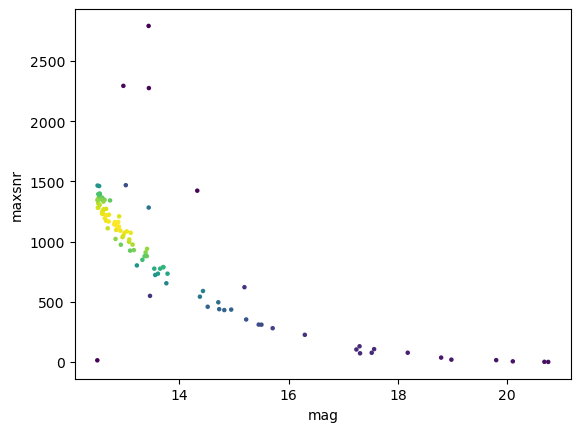

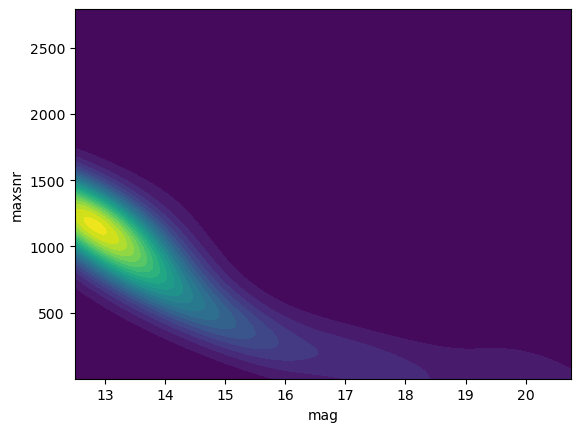

In [21]:
from scipy.stats import gaussian_kde

maxsnr = maxsnr.dropna()
x = maxsnr["mag"]
y = maxsnr["maxsnr"]

xy = np.vstack([x, y])
kde = gaussian_kde(xy)
z = kde(xy)

fig, ax = plt.subplots()
ax.scatter(x, y, c=z, s=5, cmap="viridis")
ax.set_xlabel("mag")
ax.set_ylabel("maxsnr")
plt.show()

xgrid = np.linspace(x.min(), x.max(), 200)
ygrid = np.linspace(y.min(), y.max(), 200)
X, Y = np.meshgrid(xgrid, ygrid)
positions = np.vstack([X.ravel(), Y.ravel()])
Z = kde(positions).reshape(X.shape)

fig, ax = plt.subplots()
ax.contourf(X, Y, Z, levels=20, cmap="viridis")
ax.set_xlabel("mag")
ax.set_ylabel("maxsnr")
plt.show()